### Determine the Number of Layers

In [1]:
from helperfunctions import training_lib as tl
from helperfunctions import intern_constants as ic
from helperfunctions import helper as hfn
from helperfunctions.pretty_print import PrettyPrint as pp
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm

In [ ]:
cfg1 = hfn.TrainConfig(config_name="layers_new_wd_09", epochs=10, width_decay=0.9, n_restarts=5, patience=10, min_delta=0,lr=1e-3, weight_decay=1e-2)
cfg2 = hfn.TrainConfig(config_name="layers_new_wd_075", epochs=10, width_decay=0.75, n_restarts=5, patience=10, min_delta=0,lr=1e-3, weight_decay=1e-2)
cfg4 = hfn.TrainConfig(config_name="layers_new_wd_05", epochs=10, width_decay=0.5, n_restarts=5, patience=10, min_delta=0,lr=1e-3, weight_decay=1e-2)

{
  "config_name": "layers_new_wd_09",
  "batch_size": 252,
  "epochs": 10,
  "lr": 0.001,
  "weight_decay": 0.01,
  "grad_clip_norm": 1.0,
  "patience": 10,
  "min_delta": 0,
  "depth": null,
  "input_dim": 38,
  "base_width": 38,
  "width_decay": 0.9,
  "bottleneck_min": 2,
  "activation": "relu",
  "dropout": 0.0,
  "leaky_relu_slope": null,
  "seed": 32,
  "base_seed": 32,
  "T0": 10,
  "Tmult": 2,
  "eta_min_lower_bound": 1e-06,
  "val_split": 0.4,
  "layer_depths": [
    2,
    3,
    4,
    5
  ],
  "available_start": "2019-04-05 14:00:00",
  "available_end": "2022-12-31 23:50:00",
  "min_gap": 4320,
  "val_start_time": "2019-05-13 13:00:00",
  "val_end_time": "2019-10-06 22:20:00",
  "test_start_time": "2020-05-01 04:10:00",
  "test_end_time": "2022-12-31 23:50:00",
  "signal_cols": [
    "Ambient temperature (converter) (°C)",
    "Drive train acceleration (mm/ss)",
    "Gear oil inlet pressure (bar)",
    "Gear oil pump pressure (bar)",
    "Gearbox speed (RPM)",
    "Generat

### Determining max. depth of the network

In [3]:
cfg1.layer_depths = tl.max_depth_for_width_decay(cfg1.base_width, cfg1.width_decay, cfg1.bottleneck_min)
cfg2.layer_depths = tl.max_depth_for_width_decay(cfg2.base_width, cfg2.width_decay, cfg2.bottleneck_min)
# cfg3.layer_depths = tl.max_depth_for_width_decay(cfg3.base_width, cfg3.width_decay, cfg3.bottleneck_min)
cfg4.layer_depths = tl.max_depth_for_width_decay(cfg4.base_width, cfg4.width_decay, cfg4.bottleneck_min)

cfg1.layer_depths = cfg1.layer_depths[14:]
cfg2.layer_depths = cfg2.layer_depths[5:]
cfg4.layer_depths = cfg4.layer_depths[2:]
print(f"cfg1: layer_depths={cfg1.layer_depths}")
print(f"cfg2: layer_depths={cfg2.layer_depths}")
print(f"cfg4: layer_depths={cfg4.layer_depths}")

cfg1: layer_depths=[15, 16, 17, 18, 19, 20]
cfg2: layer_depths=[6, 7, 8, 9]
cfg4: layer_depths=[3, 4]


In [ ]:
cfg_list = [cfg1, 
            cfg2,
            cfg4,
            ]

print(cfg1.layer_depths)


[15, 16, 17, 18, 19, 20]


In [6]:
print(f"val_start_time: {cfg1.val_start_time}\n"
      f"val_end_time: {cfg1.val_end_time}\n"
      f"test_start_time: {cfg1.test_start_time}\n"
      f"test_start_end: {cfg1.test_end_time}\n")

val_start_time: 2019-05-13 13:00:00
val_end_time: 2019-10-06 22:20:00
test_start_time: 2020-05-01 04:10:00
test_start_end: 2022-12-31 23:50:00



In [ ]:
train_loader, val_loader, test_loader = hfn.build_dataloaders(
                  train_csv_dir=ic.PATH_PC_FILTERING,
                  val_csv_dir=ic.PATH_IMPUTED,
                  test_csv_dir=ic.PATH_IMPUTED,
                  cfg=cfg1
                  )

  0%|          | 0/6 [00:00<?, ?it/s]

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

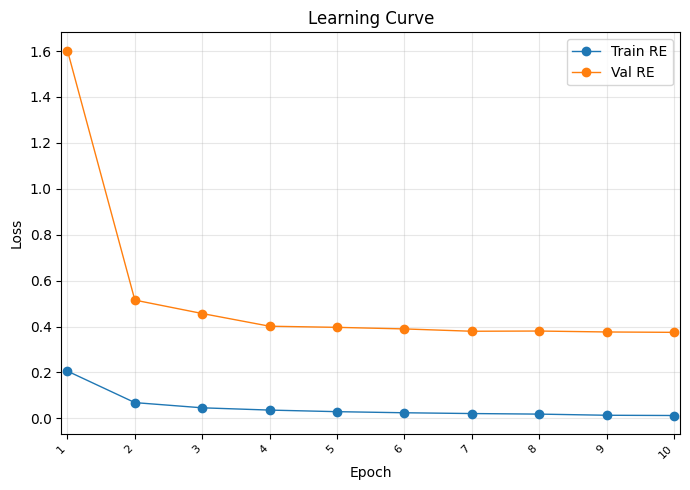

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

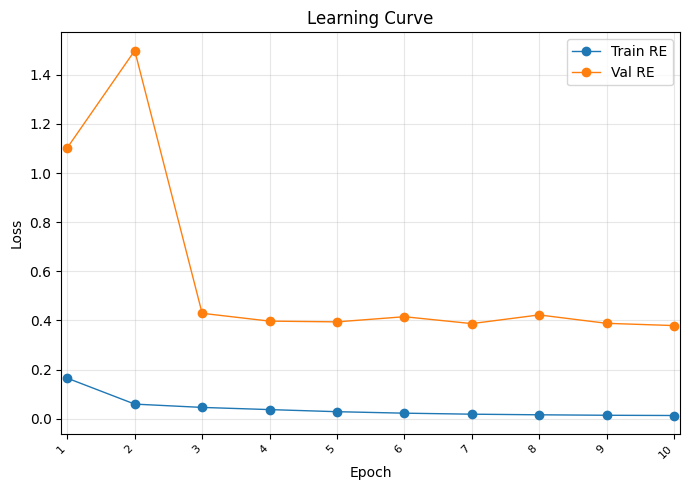

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

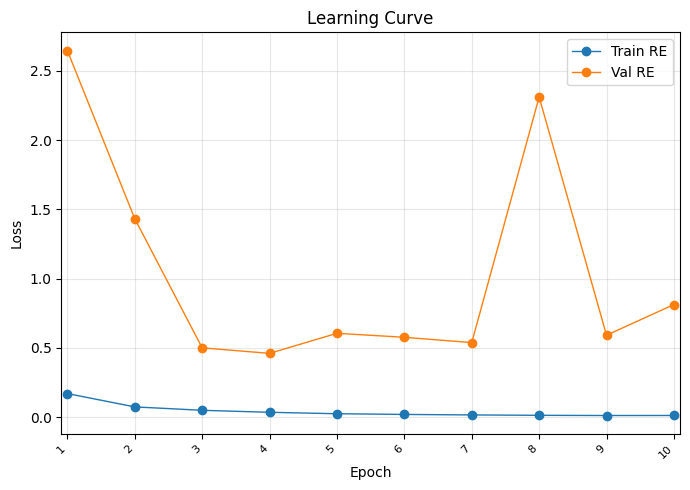

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

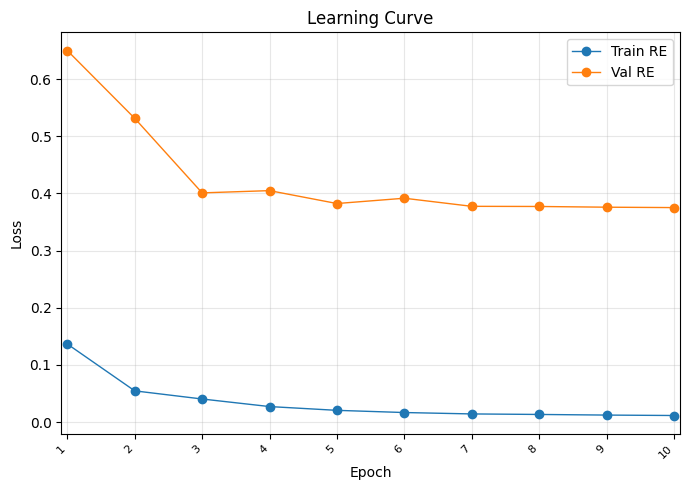

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

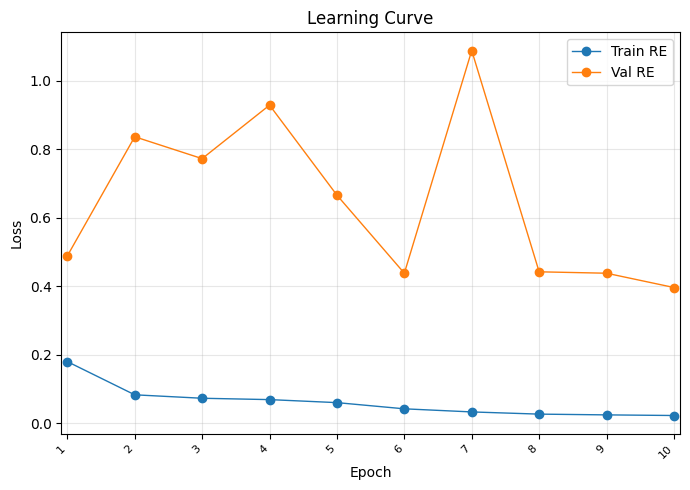

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

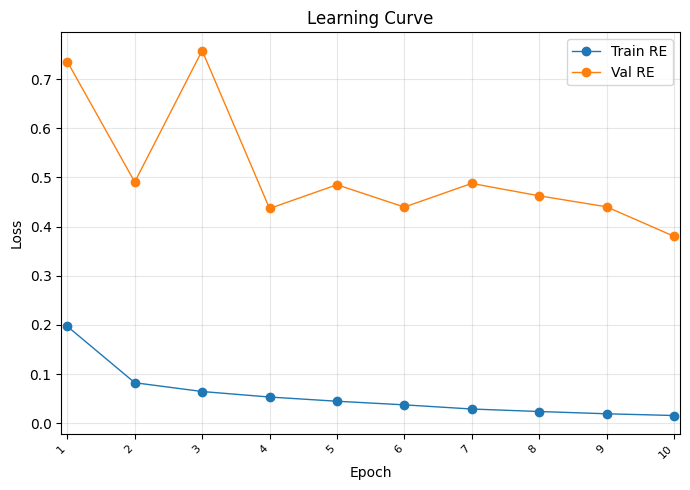

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

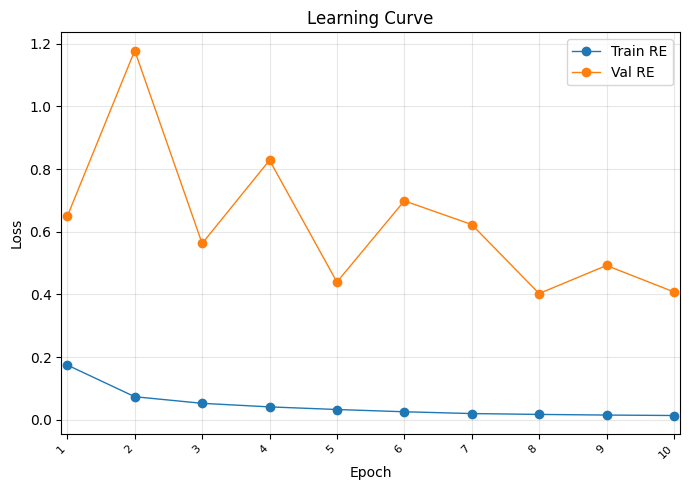

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

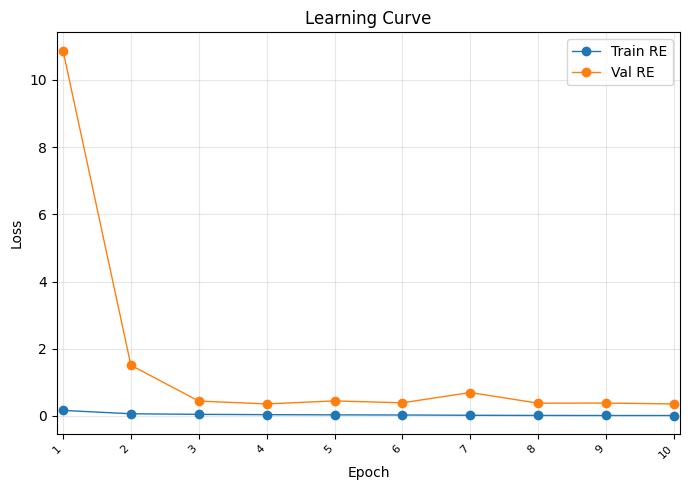

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

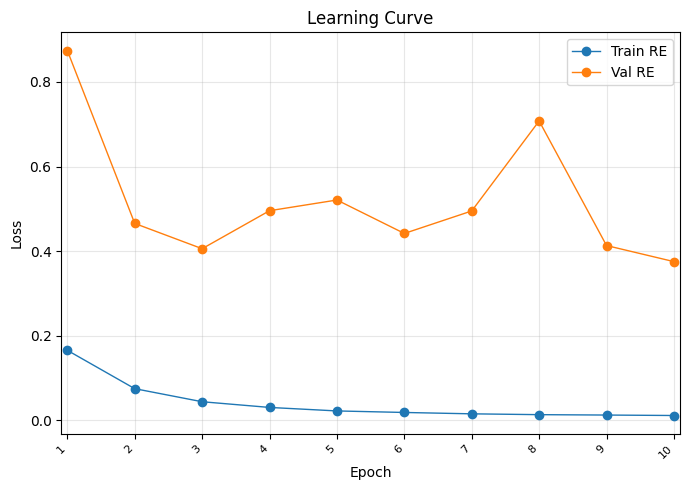

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

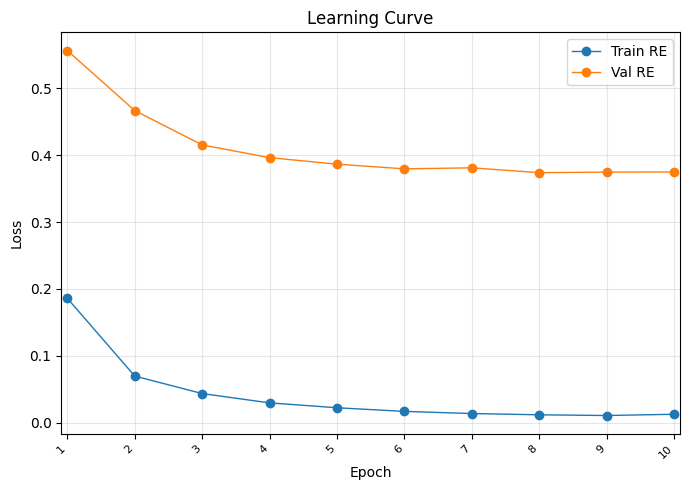

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

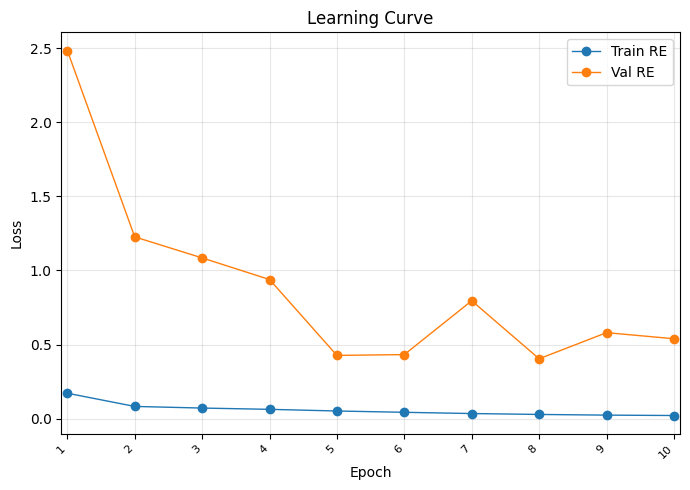

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

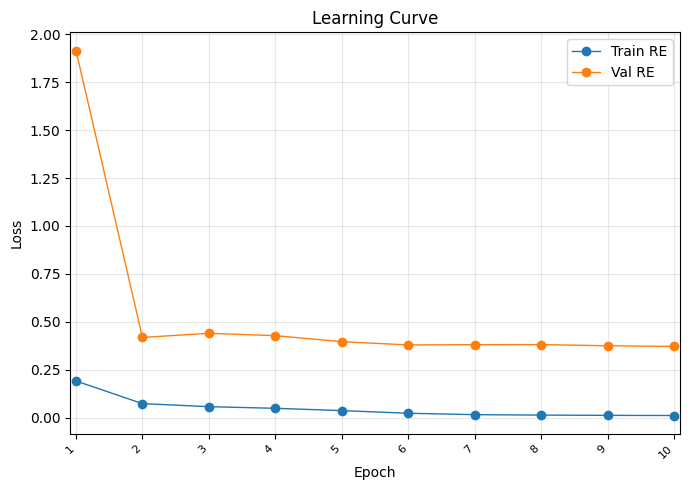

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

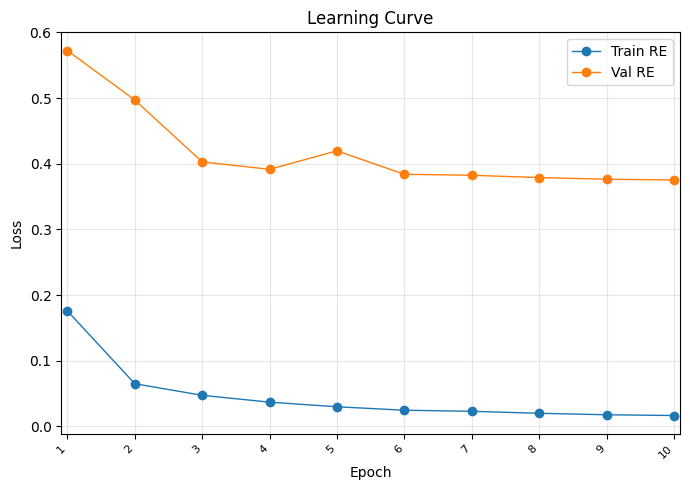

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

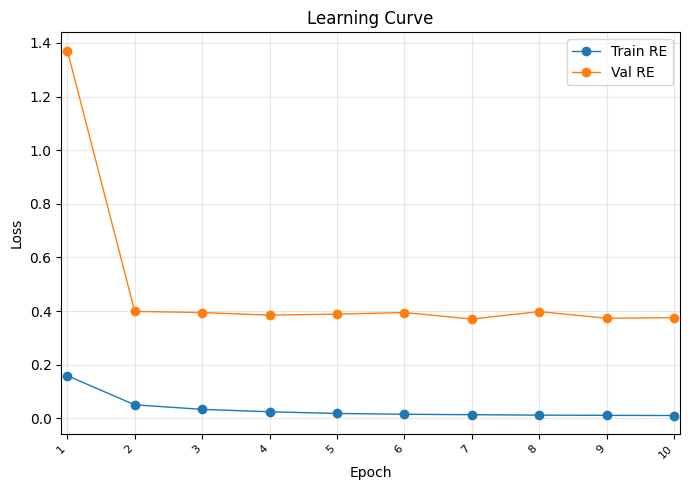

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

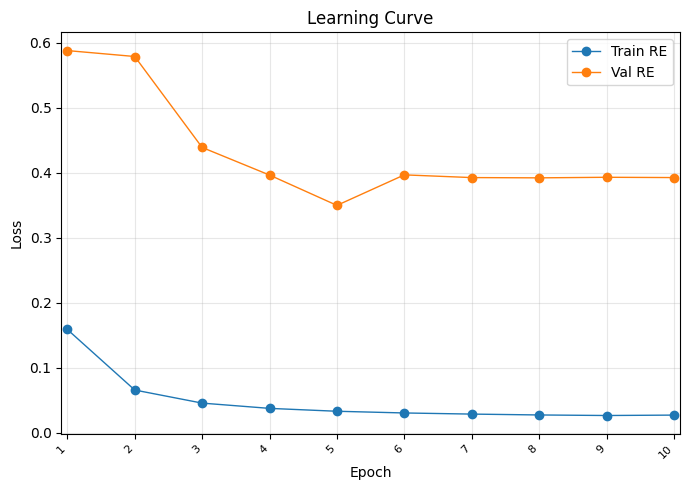

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

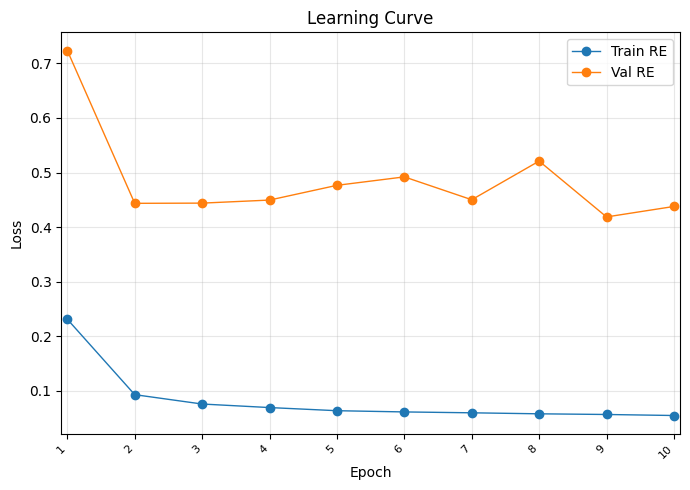

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

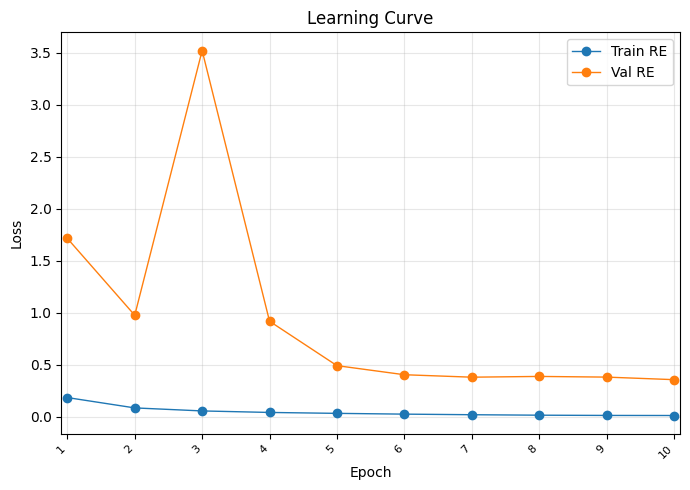

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

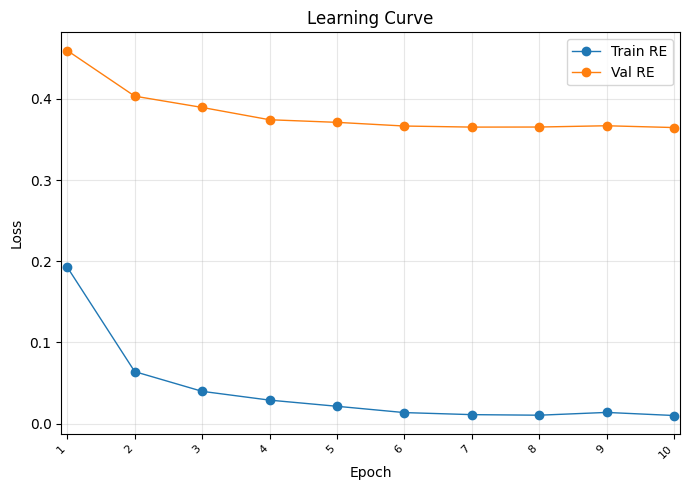

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

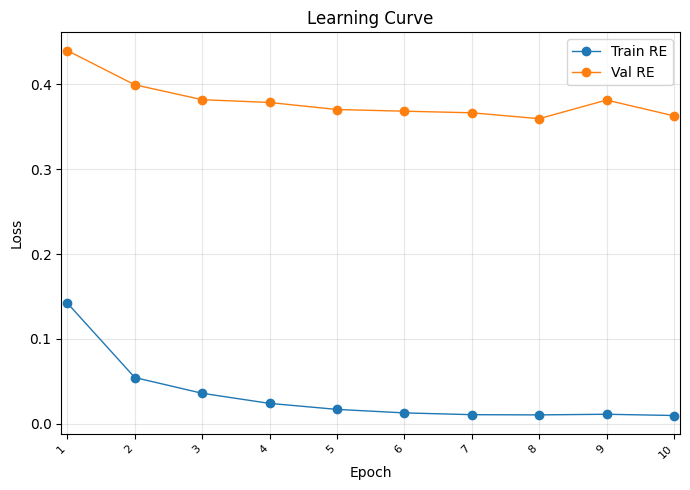

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

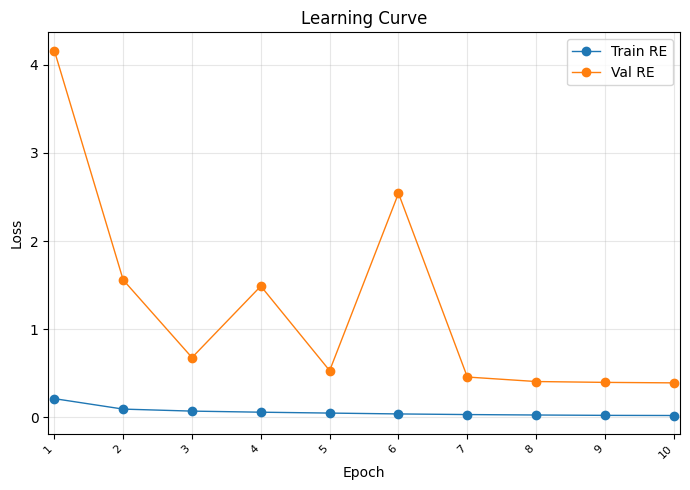

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

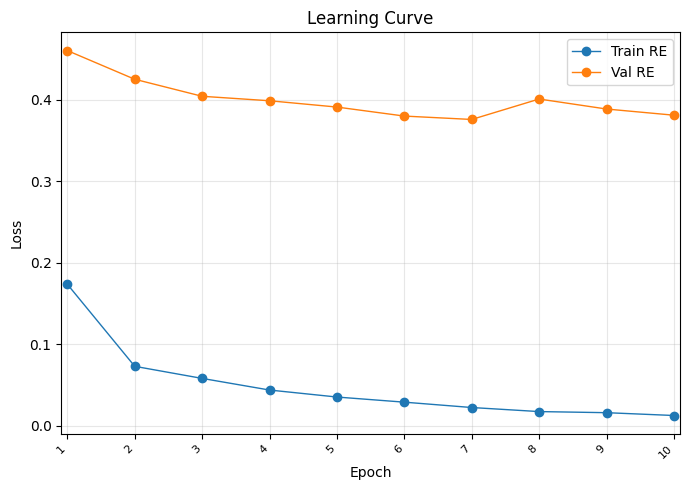

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

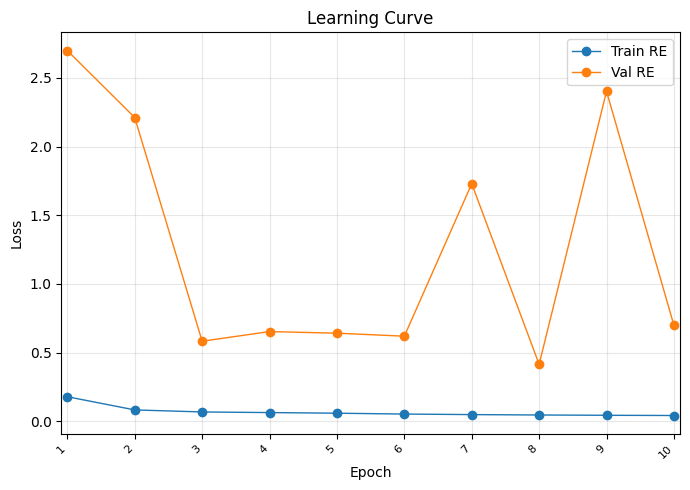

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

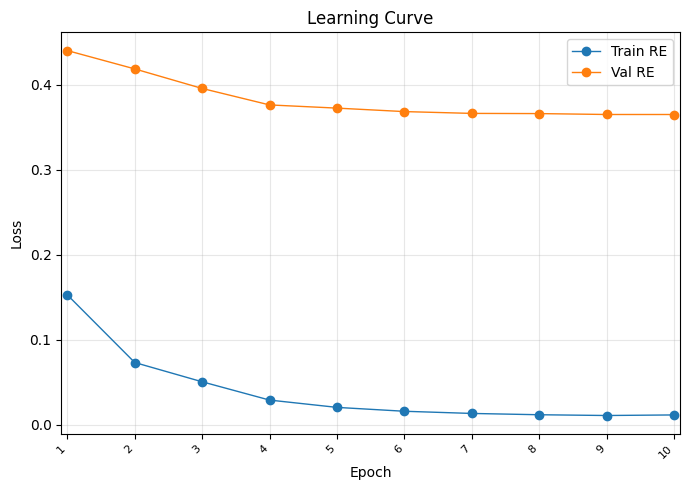

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

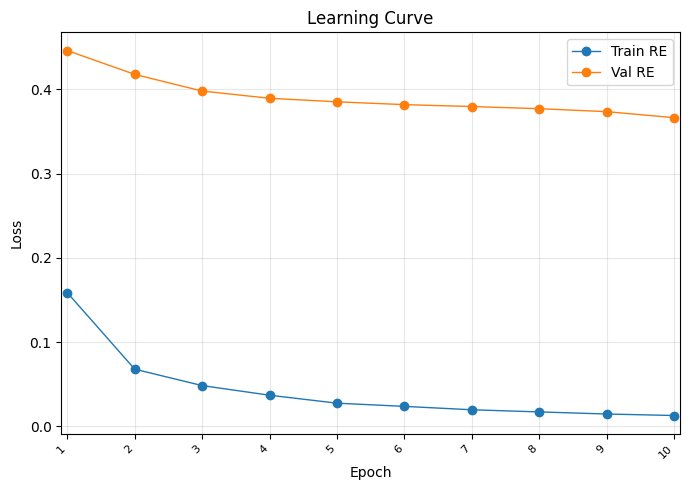

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

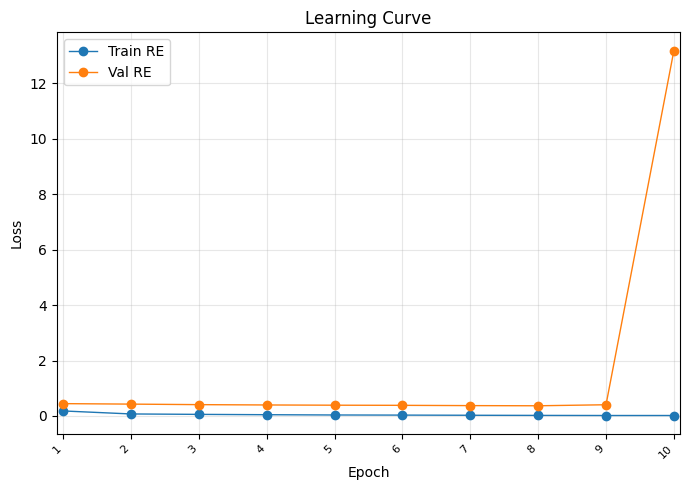

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

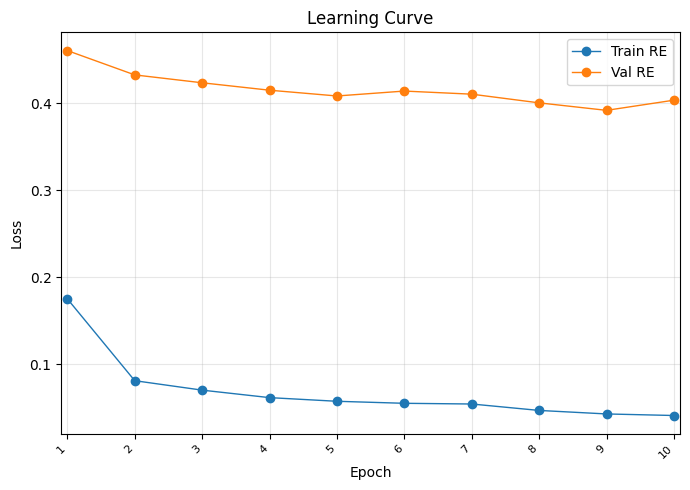

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

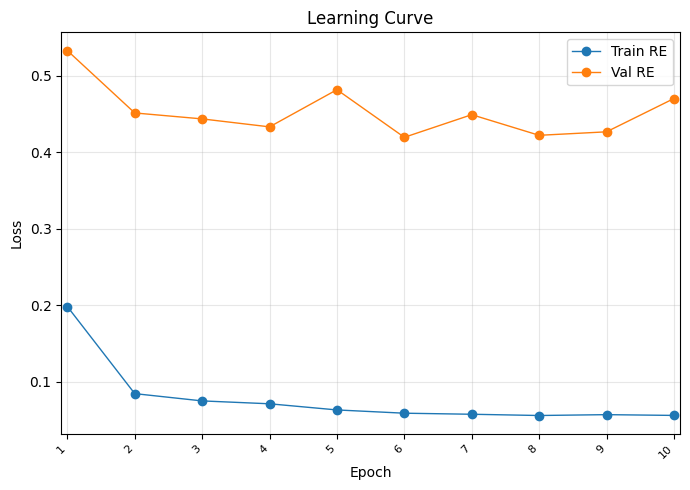

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

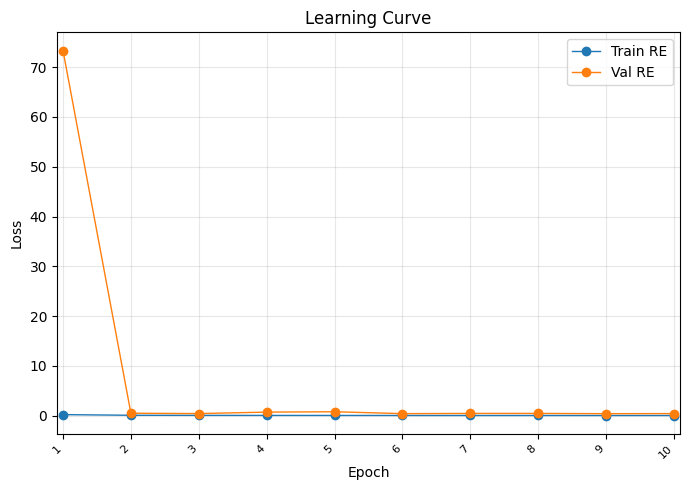

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

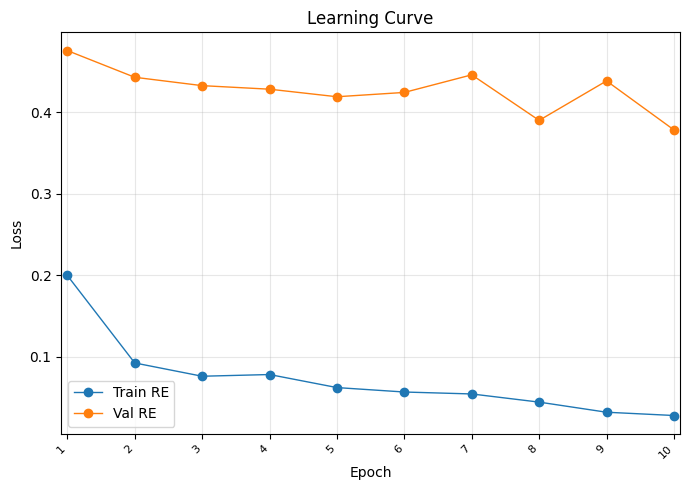

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

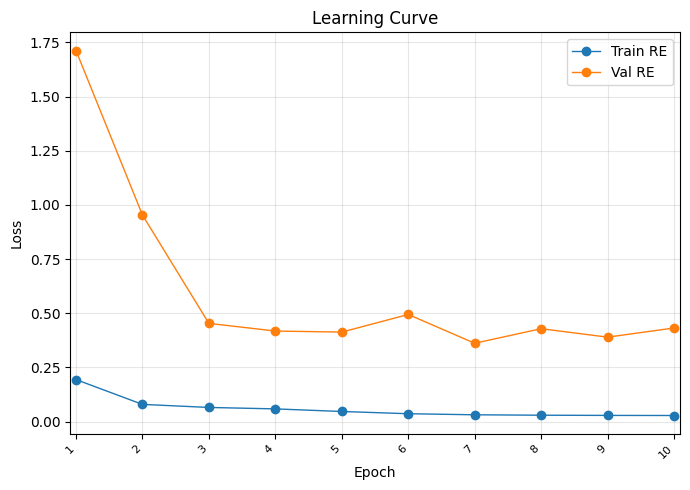

  0%|          | 0/4 [00:00<?, ?it/s]

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

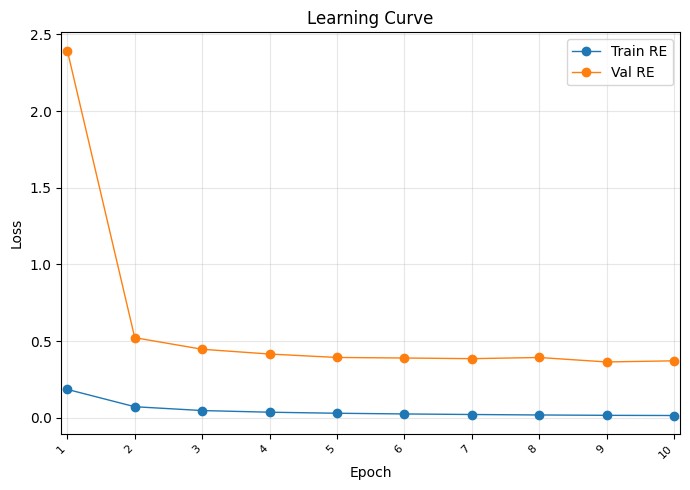

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

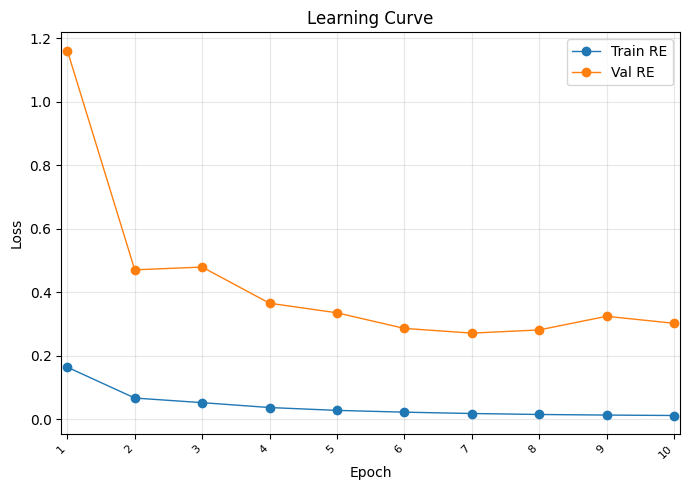

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

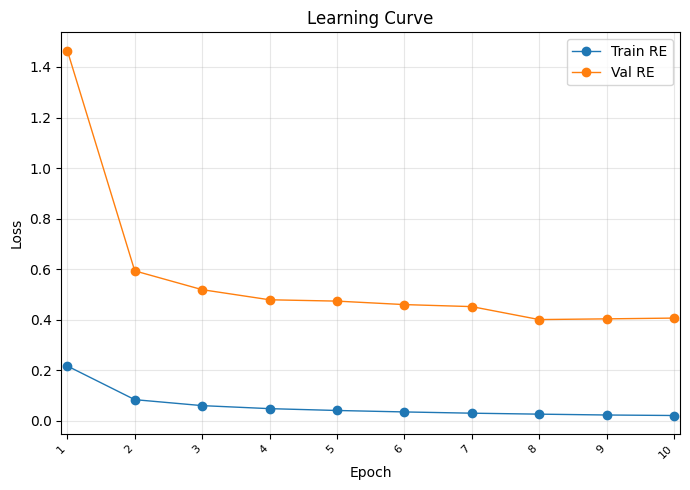

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

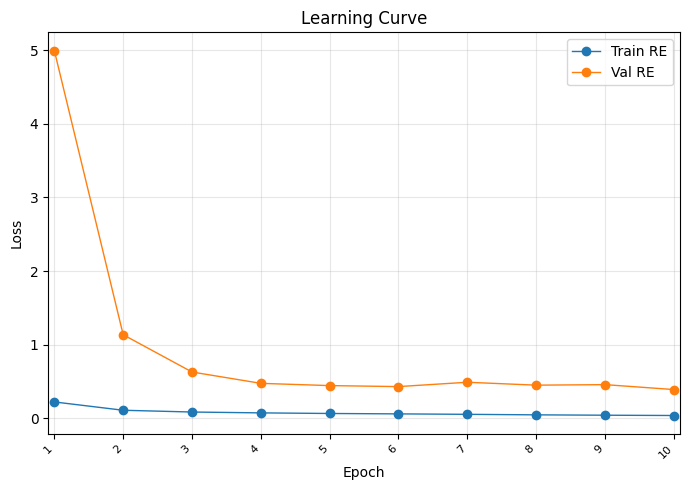

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

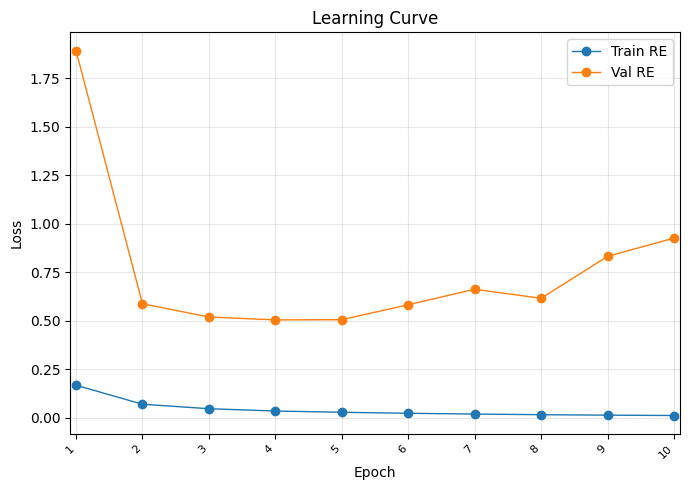

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

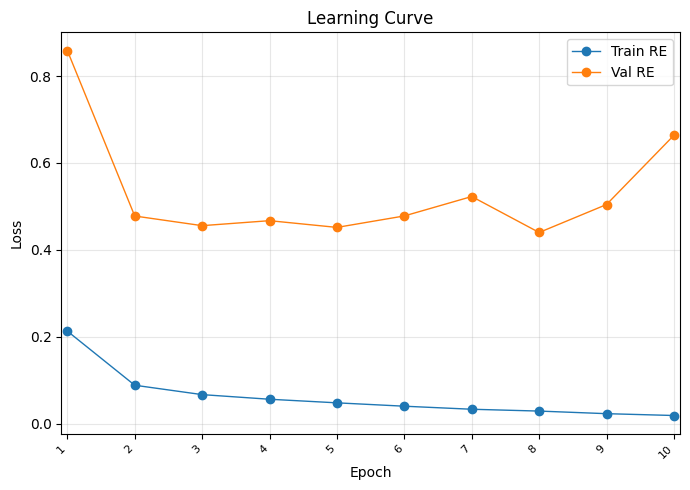

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

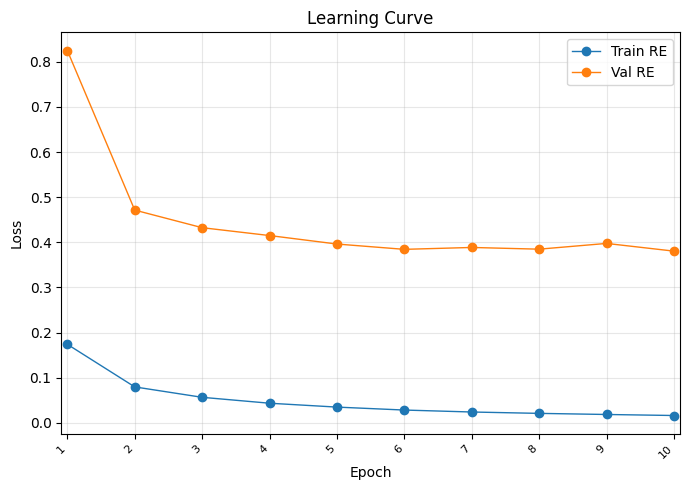

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

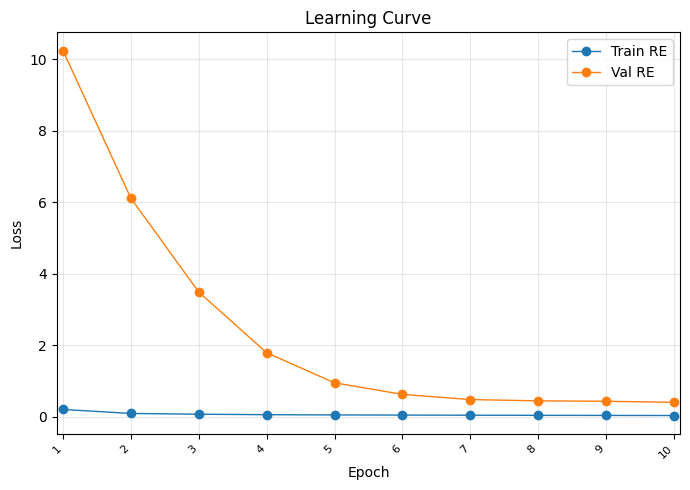

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

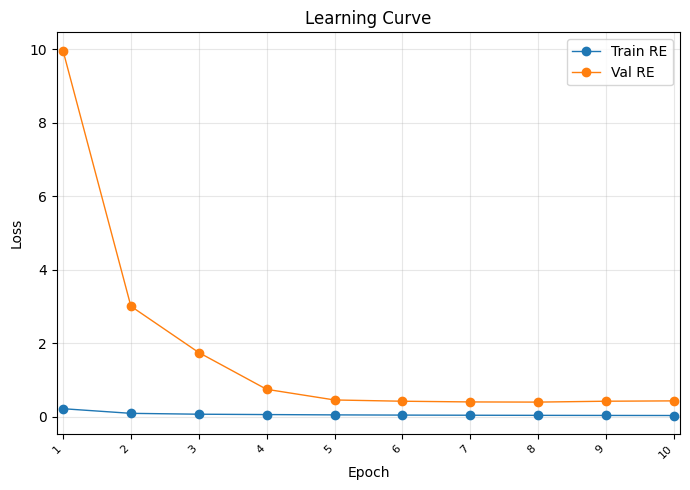

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

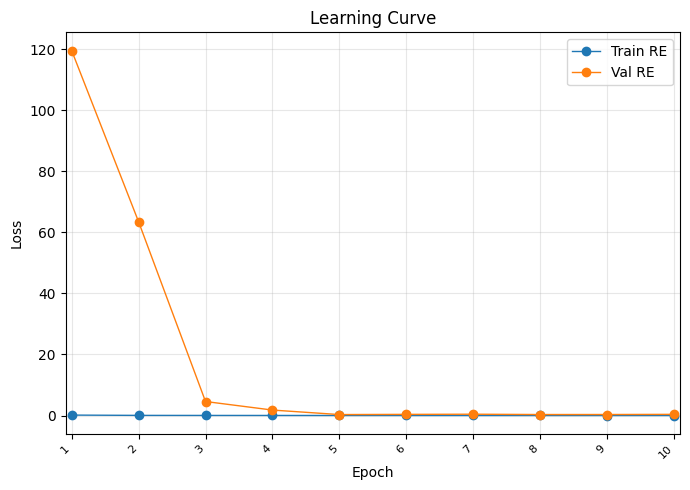

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

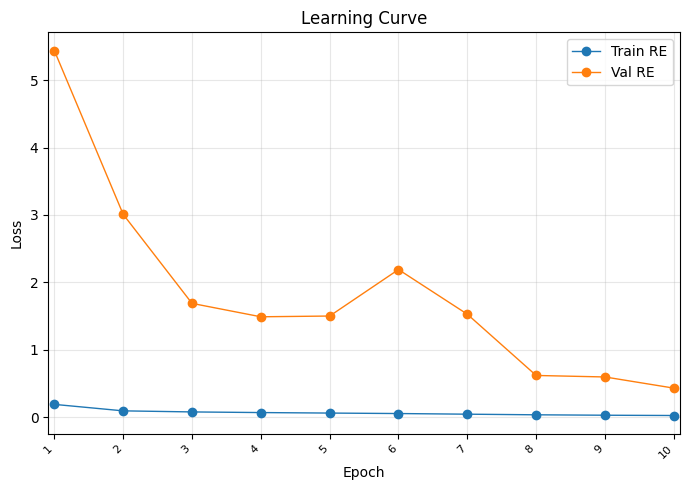

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

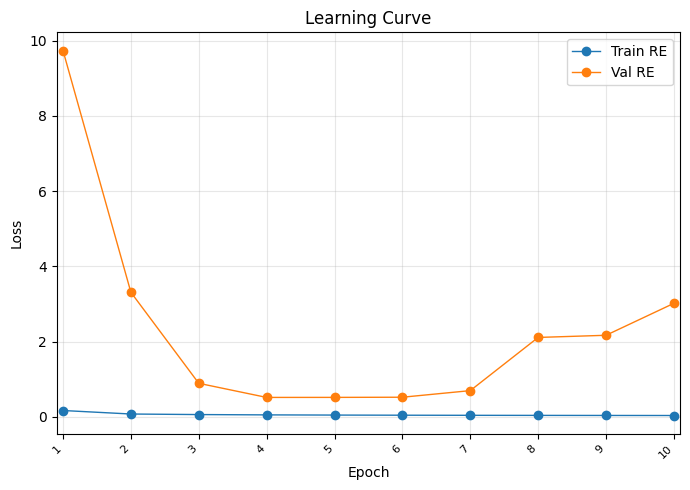

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

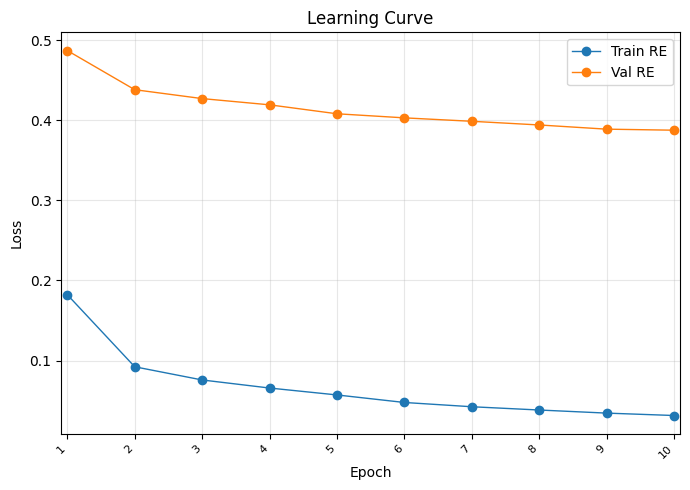

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

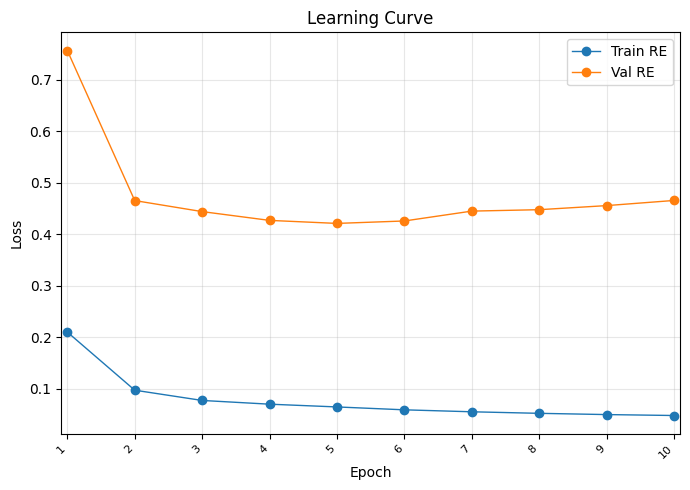

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

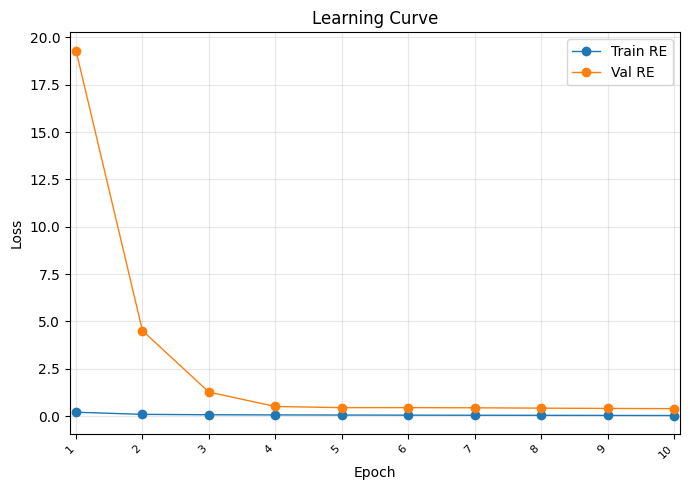

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

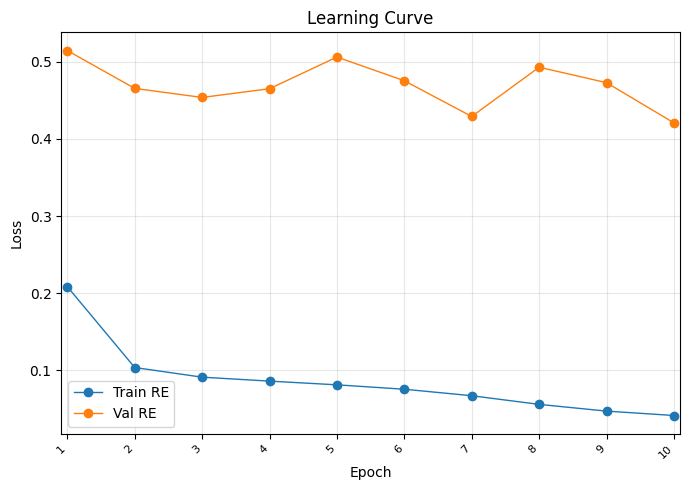

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

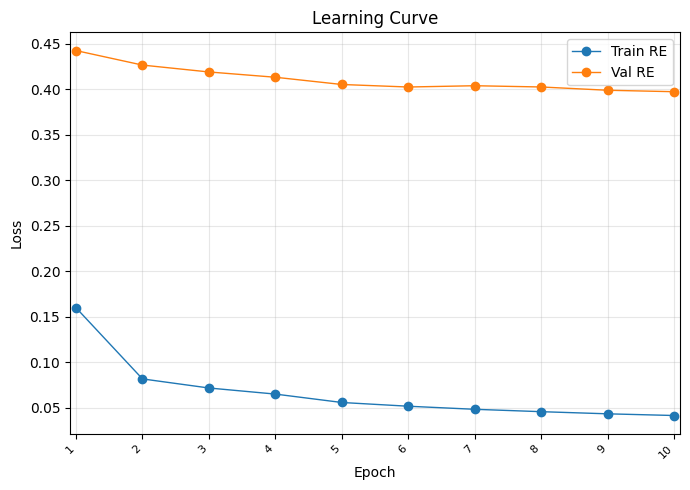

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

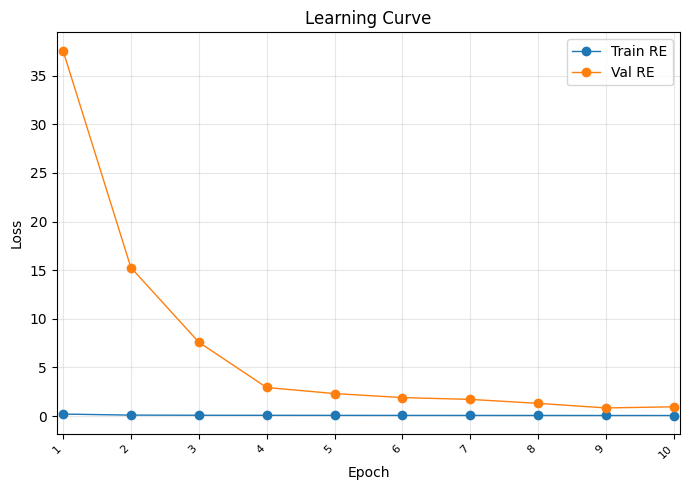

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

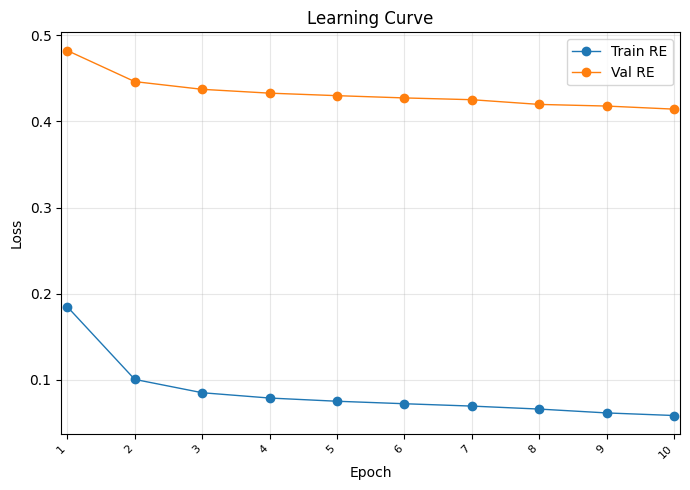

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

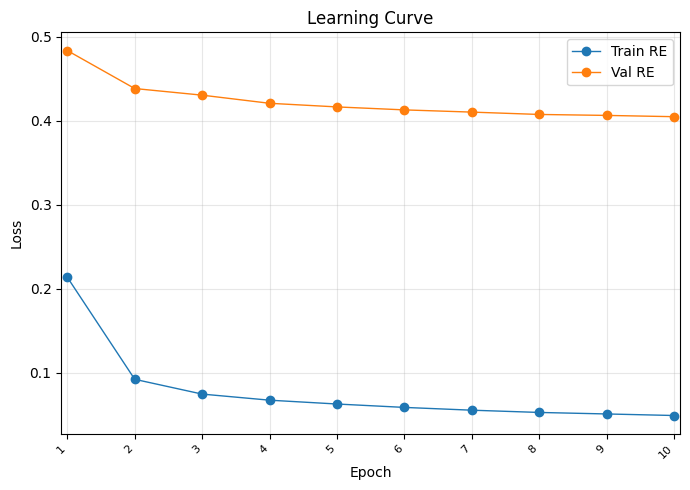

  0%|          | 0/2 [00:00<?, ?it/s]

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

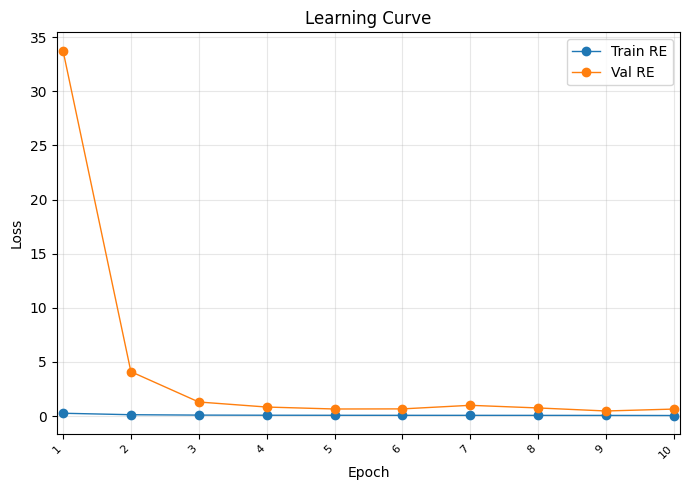

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

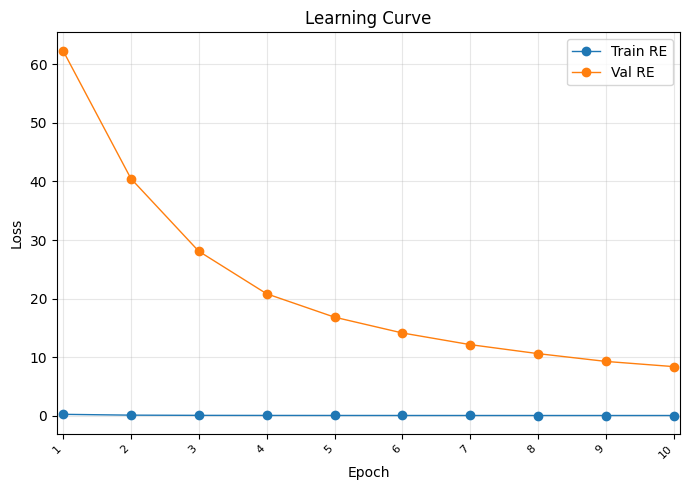

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

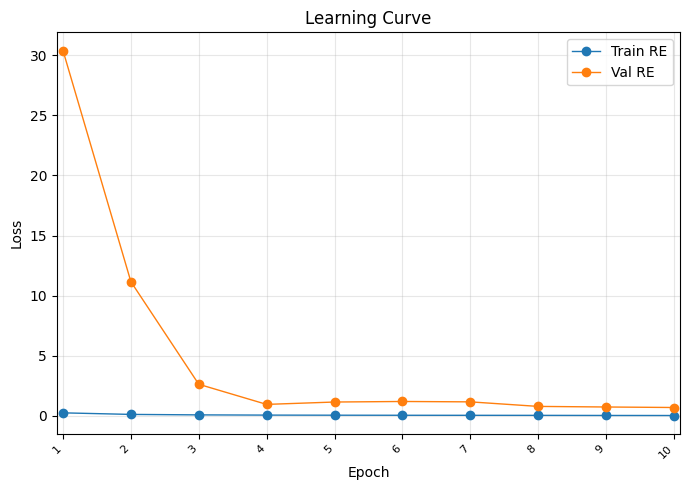

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

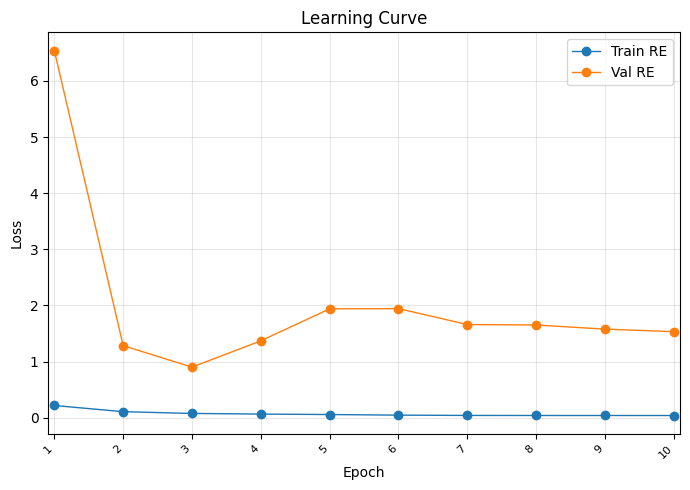

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

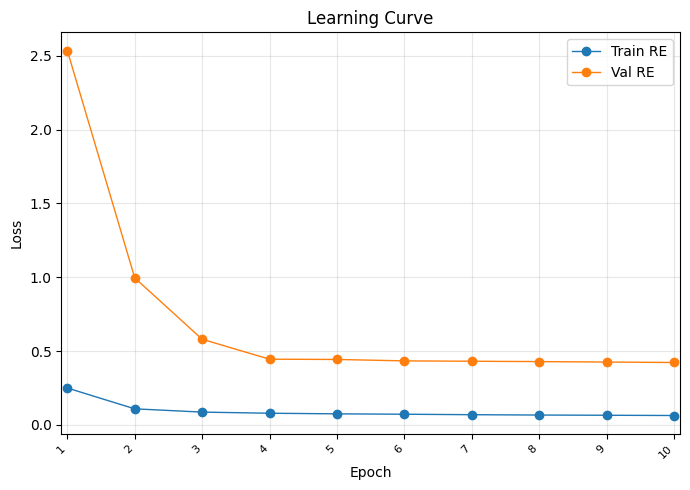

Epochs:   0%|          | 0/10 [00:00<?, ?ep/s]

In [ ]:
scaler = torch.amp.GradScaler() if torch.cuda.is_available() else None
for cfg in cfg_list:

    depths = cfg.layer_depths

    for depth in tqdm(depths):
        
        cfg.depth = int(depth)
        cfg.config_name= f"layers_{depth}"
        
        for i in range(0, cfg.n_restarts):
            # cfg.seed = cfg.seed_list[i]
            cfg.set_seed(cfg.seed_list[i])
            model = tl.Autoencoder(cfg=cfg).to(cfg.device)
            optimizer = optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
            
            loss_fn = nn.MSELoss(reduction="none")
            es = tl.EarlyStopping(min_delta=cfg.min_delta, patience=cfg.patience)
            
            results_es, _= tl.train_with_early_stopping(
                                                        model,
                                                        train_loader=train_loader,
                                                        val_loader= val_loader,
                                                        optimizer=optimizer,
                                                        config=cfg,
                                                        es=es,
                                                        loss_fn=loss_fn,
                                                        filename_prefix=f"cfg-{cfg.config_name}-layer_depths_{depth}_seed_{cfg.seed}_decay_{cfg.width_decay}",
                                                        scaler=scaler,
                                                        )
            train_loader = hfn.rebuild_grouped_loader(train_loader,
                                                seed=cfg.seed, 
                                                shuffle=True, 
                                                batch_size=cfg.batch_size)
            val_loader = hfn.rebuild_grouped_loader(val_loader, 
                                                seed=cfg.seed,
                                                shuffle=False,
                                                batch_size=cfg.batch_size)
            pp.print_learning_curve(results_es["history"], save_dir=results_es["dir_path"])

In [ ]:
model, (min,max) = tl.get_model_results(ic.PATH_TO_BEST_MODEL_DIR,best_n=1, report_min_max=False)

C:\Users\admin\AppData\Roaming\Python\Python312\site-packages\torch\amp\grad_scaler.py:132: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(


name:activation__Seed_32_uid_8c8d353bea.pth
 best val error:0.17704901592204464
 best train error:0.009280807258664099
 model params:5425

